<a href="https://colab.research.google.com/github/muhammad-faizan087/Machine-Learning-Projects/blob/main/Unsupervised%20learning/DB_SCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DB SCAN -> Density based algorithm



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

make_moons is used to make dummy datasets (in which samples are distributed in moons shape), used as a dummy dataset for clustering algos

In [ ]:
X, y = make_moons(n_samples=500, noise=0.05, random_state=42)

In [ ]:
df = pd.DataFrame(X, columns=['feature1', 'feature2'])
df.head()

,feature1,feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [ ]:
df_scaled = df.copy()
scaler = StandardScaler()
df_scaled[df.columns] = scaler.fit_transform(df[df.columns])
df_scaled.head()

,feature1,feature2
0,0.375125,-1.403679
1,0.226815,1.135628
2,0.595442,-1.493710
3,-0.944918,1.409748
4,-0.243115,1.618062


In [ ]:
inertia = []
k_range = range(1,10)
for k in k_range:
  k_model = KMeans(n_clusters=k)
  k_model.fit(df_scaled)
  inertia.append(k_model.inertia_)

Text(0.5, 1.0, 'Elbow method')

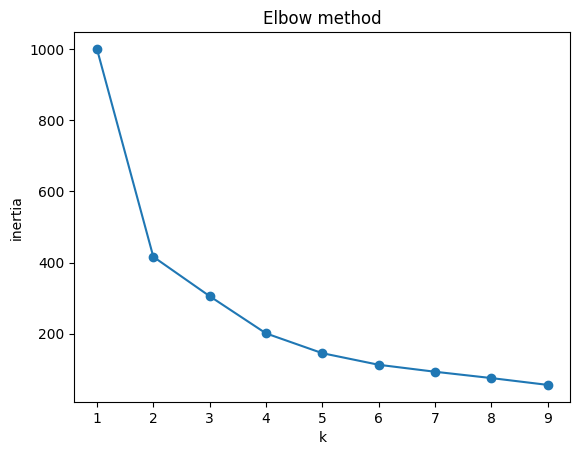

In [ ]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel('k')
plt.ylabel('inertia')
plt.title('Elbow method')

In [ ]:
k_final = KMeans(n_clusters=2)
cluster_labels = k_final.fit_predict(df_scaled)
df['cluster'] = cluster_labels
df.head()

,feature1,feature2,cluster
0,0.830586,-0.447733,0
1,0.701678,0.816918,1
2,1.022080,-0.492571,0
3,-0.316765,0.953438,1
4,0.293226,1.057185,1


<Axes: xlabel='feature1', ylabel='feature2'>

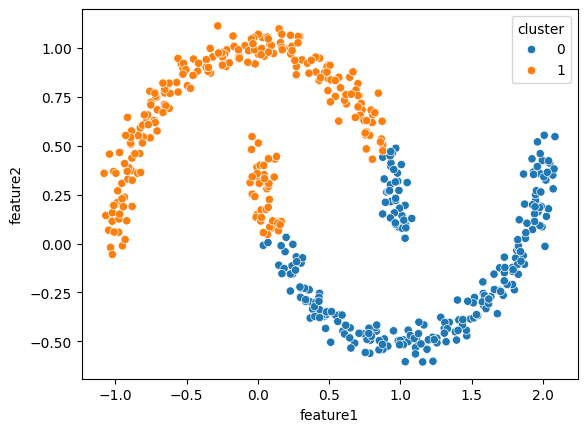

In [ ]:
sns.scatterplot(data=df, x='feature1', y='feature2', hue='cluster')

In [ ]:
Db_model = DBSCAN(eps=0.3, min_samples=5)
Db_clusters = Db_model.fit_predict(X=df_scaled)
df['db_cluster'] = Db_clusters
df.head()

,feature1,feature2,cluster,db_cluster
0,0.830586,-0.447733,0,0
1,0.701678,0.816918,1,1
2,1.022080,-0.492571,0,0
3,-0.316765,0.953438,1,1
4,0.293226,1.057185,1,1


<Axes: xlabel='feature1', ylabel='feature2'>

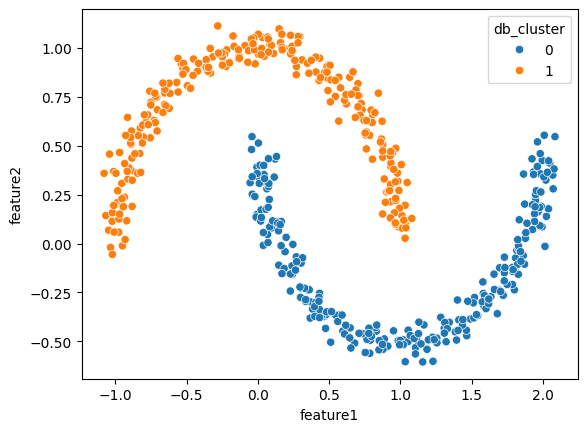

In [ ]:
sns.scatterplot(data=df, x='feature1', y='feature2', hue='db_cluster')